In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

Saving barcode1.jpg to barcode1.jpg


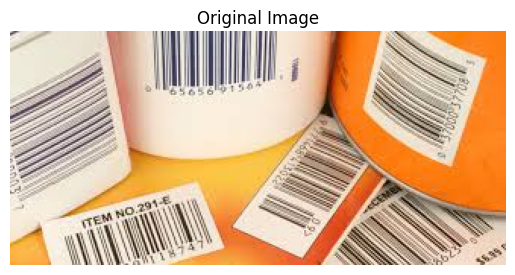

In [2]:
# ---------------- Image loading and preview ----------------

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

image = cv.imread(image_path)

plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')
plt.show()

Combined gradient shape: (154, 327)


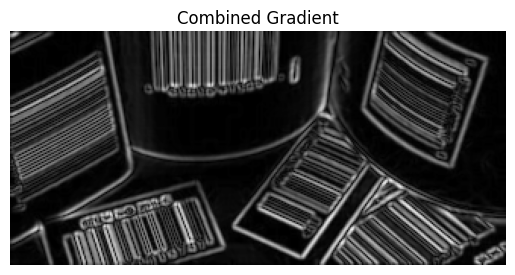

In [3]:
# ---------------- Preprocessing + Gradient (orientation independent) ----------------

gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
blurred = cv.GaussianBlur(gray, (5, 5), 0)

# Gradients in both directions
grad_x = cv.Sobel(blurred, cv.CV_32F, 1, 0, ksize=3)
grad_y = cv.Sobel(blurred, cv.CV_32F, 0, 1, ksize=3)

# Convert to absolute
abs_x = cv.convertScaleAbs(grad_x)
abs_y = cv.convertScaleAbs(grad_y)

# Combine – this picks strong edges in ANY direction
grad_combined = cv.addWeighted(abs_x, 0.5, abs_y, 0.5, 0)

print("Combined gradient shape:", grad_combined.shape)
plt.imshow(grad_combined, cmap='gray')
plt.title("Combined Gradient")
plt.axis('off')
plt.show()



Binary:


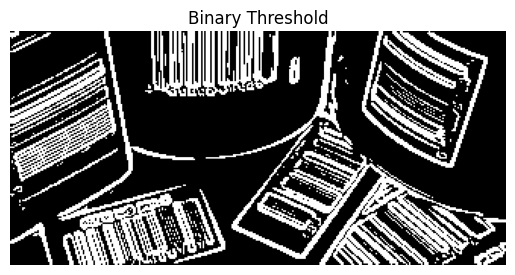

After light morphology:


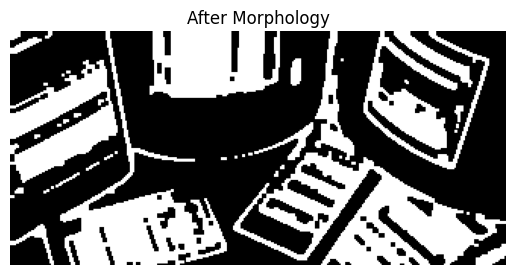

In [4]:
# ---------------- Threshold + Very Light Morphology ----------------

# 1) Binary mask from combined gradient
_, binary = cv.threshold(
    grad_combined, 0, 255,
    cv.THRESH_BINARY | cv.THRESH_OTSU
)

# 2) VERY SMALL closing to avoid merging barcodes
kernel_close = cv.getStructuringElement(cv.MORPH_RECT, (3, 3))
closed = cv.morphologyEx(binary, cv.MORPH_CLOSE, kernel_close, iterations=1)

# 3) Light opening to clear noise
kernel_open = cv.getStructuringElement(cv.MORPH_RECT, (2, 2))
clean = cv.morphologyEx(closed, cv.MORPH_OPEN, kernel_open, iterations=1)

print("Binary:")
plt.imshow(binary, cmap='gray')
plt.title("Binary Threshold")
plt.axis('off')
plt.show()

print("After light morphology:")
plt.imshow(clean, cmap='gray')
plt.title("After Morphology")
plt.axis('off')
plt.show()



In [5]:
mask = clean.copy()

contours, _ = cv.findContours(
    mask,
    cv.RETR_EXTERNAL,
    cv.CHAIN_APPROX_SIMPLE
)

output = image.copy()
img_h, img_w = image.shape[:2]

# Threshold for detecting merged barcodes (adjust based on typical barcode size)
LARGE_AREA_THRESHOLD = 3000  # Lowered to catch more merged cases

# Store all barcode candidates (box, area, center) for NMS
barcode_candidates = []

In [6]:
def validate_contour(cnt, img_width, img_height):
    """Validate if a contour looks like a barcode, return bounding box info or None"""
    area = cv.contourArea(cnt)

    # 1) Ignore tiny
    if area < 500:
        return None

    # Use axis-aligned box only for filtering logic
    x, y, w, h = cv.boundingRect(cnt)

    # 2) Ignore something that covers almost the whole image
    if w > 0.95 * img_width and h > 0.95 * img_height:
        return None

    # 3) kill microscopic Barcodes
    if w < 20 or h < 15:
        return None

    # 4) Kill small almost-square
    if w < 35 and h < 35:
        return None

    # 5) Aspect ratio check: remove weird shapes
    aspect_ratio = w / float(h)
    if aspect_ratio < 0.5 or aspect_ratio > 8.0:
        return None

    # Get rotating bounding box
    rect = cv.minAreaRect(cnt)
    box = cv.boxPoints(rect)
    box = box.astype(np.int32)

    # Calculate center and area for NMS
    center = rect[0]
    box_area = rect[1][0] * rect[1][1]

    return {
        'box': box,
        'area': box_area,
        'center': center,
        'rect': rect,
        'contour': cnt
    }

def calculate_iou(box1, box2):
    """Calculate Intersection over Union (IoU) of two rotated bounding boxes"""
    # Convert to axis-aligned bounding boxes for simpler IoU calculation
    x1, y1, w1, h1 = cv.boundingRect(box1)
    x2, y2, w2, h2 = cv.boundingRect(box2)

    # Calculate intersection
    x_left = max(x1, x2)
    y_top = max(y1, y2)
    x_right = min(x1 + w1, x2 + w2)
    y_bottom = min(y1 + h1, y2 + h2)

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    intersection = (x_right - x_left) * (y_bottom - y_top)
    area1 = w1 * h1
    area2 = w2 * h2
    union = area1 + area2 - intersection

    if union == 0:
        return 0.0

    return intersection / union

def calculate_distance(center1, center2):
    """Calculate Euclidean distance between two centers"""
    return np.sqrt((center1[0] - center2[0])**2 + (center1[1] - center2[1])**2)

def non_max_suppression(candidates, iou_threshold=0.15, distance_threshold=50):
    """Remove overlapping detections using Non-Maximum Suppression with distance filtering"""
    if len(candidates) == 0:
        return []

    # Sort by area (largest first) - keep larger detections
    candidates_sorted = sorted(candidates, key=lambda x: x['area'], reverse=True)

    keep = []
    while len(candidates_sorted) > 0:
        # Take the largest one
        current = candidates_sorted.pop(0)
        keep.append(current)

        # Remove all that overlap too much OR are too close to current
        remaining = []
        for candidate in candidates_sorted:
            iou = calculate_iou(current['box'], candidate['box'])
            distance = calculate_distance(current['center'], candidate['center'])

            # Keep only if: low overlap AND far enough away
            # Or if it's a significantly different size (might be a different barcode)
            size_ratio = min(current['area'], candidate['area']) / max(current['area'], candidate['area'])

            if iou < iou_threshold and (distance > distance_threshold or size_ratio < 0.3):
                remaining.append(candidate)

        candidates_sorted = remaining

    return keep

def split_large_contour(roi_mask, x_offset, y_offset, img_w, img_h):
    best_candidates = []

    # Strategy 1:horizontal erosion
    kernel_h = cv.getStructuringElement(cv.MORPH_RECT, (9, 2))
    eroded_h = cv.erode(roi_mask, kernel_h, iterations=4)
    sub_contours_h, _ = cv.findContours(eroded_h, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

    temp_candidates = []
    for sub_cnt in sub_contours_h:
        sub_cnt_adjusted = sub_cnt + np.array([[x_offset, y_offset]], dtype=np.int32)
        candidate = validate_contour(sub_cnt_adjusted, img_w, img_h)
        if candidate:
            temp_candidates.append(candidate)

    if len(temp_candidates) >= 2:
        best_candidates = temp_candidates

    # Strategy 2: Horizontal projection-based splitting
    if len(best_candidates) < 2:
        # Calculate horizontal projection (sum of white pixels per column)
        h_projection = np.sum(roi_mask, axis=0)

        # Simple smoothing using convolution
        kernel_size = 5
        kernel = np.ones(kernel_size) / kernel_size
        h_projection_smooth = np.convolve(h_projection.astype(float), kernel, mode='same')

        # Indicate gaps between barcodes
        threshold = np.mean(h_projection_smooth) * 0.35  # Low threshold to find more valleys
        valleys = []
        for i in range(3, len(h_projection_smooth) - 3):
            if h_projection_smooth[i] < threshold and \
               h_projection_smooth[i] < h_projection_smooth[i-1] and \
               h_projection_smooth[i] < h_projection_smooth[i+1] and \
               h_projection_smooth[i] < h_projection_smooth[i-2] and \
               h_projection_smooth[i] < h_projection_smooth[i+2]:
                valleys.append(i)

        # If we found valleys, try splitting at multiple points
        if len(valleys) > 0:
            # Filter valleys to be in reasonable positions (not too close to edges)
            valid_valleys = [v for v in valleys if v > roi_mask.shape[1] * 0.1 and v < roi_mask.shape[1] * 0.9]

            if len(valid_valleys) > 0:
                # Try splitting at the valley closest to middle first
                middle = roi_mask.shape[1] // 2
                split_x = min(valid_valleys, key=lambda v: abs(v - middle))

                # Split the mask at this x position
                left_mask = roi_mask[:, :split_x]
                right_mask = roi_mask[:, split_x:]

                left_contours, _ = cv.findContours(left_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
                right_contours, _ = cv.findContours(right_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

                temp_candidates = []
                for sub_cnt in left_contours:
                    if cv.contourArea(sub_cnt) > 300:  # Filter tiny noise
                        sub_cnt_adjusted = sub_cnt + np.array([[x_offset, y_offset]], dtype=np.int32)
                        candidate = validate_contour(sub_cnt_adjusted, img_w, img_h)
                        if candidate:
                            temp_candidates.append(candidate)

                for sub_cnt in right_contours:
                    if cv.contourArea(sub_cnt) > 300:  # Filter tiny noise
                        sub_cnt_adjusted = sub_cnt + np.array([[x_offset + split_x, y_offset]], dtype=np.int32)
                        candidate = validate_contour(sub_cnt_adjusted, img_w, img_h)
                        if candidate:
                            temp_candidates.append(candidate)

                if len(temp_candidates) > len(best_candidates):
                    best_candidates = temp_candidates

                # If still not enough, try vertical projection for stacked barcodes
                if len(best_candidates) < 2:
                    v_projection = np.sum(roi_mask, axis=1)
                    v_projection_smooth = np.convolve(v_projection.astype(float), kernel, mode='same')
                    v_threshold = np.mean(v_projection_smooth) * 0.35
                    v_valleys = []
                    for i in range(3, len(v_projection_smooth) - 3):
                        if v_projection_smooth[i] < v_threshold and \
                           v_projection_smooth[i] < v_projection_smooth[i-1] and \
                           v_projection_smooth[i] < v_projection_smooth[i+1]:
                            v_valleys.append(i)

                    if len(v_valleys) > 0:
                        valid_v_valleys = [v for v in v_valleys if v > roi_mask.shape[0] * 0.1 and v < roi_mask.shape[0] * 0.9]
                        if len(valid_v_valleys) > 0:
                            middle_v = roi_mask.shape[0] // 2
                            split_y = min(valid_v_valleys, key=lambda v: abs(v - middle_v))

                            top_mask = roi_mask[:split_y, :]
                            bottom_mask = roi_mask[split_y:, :]

                            top_contours, _ = cv.findContours(top_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
                            bottom_contours, _ = cv.findContours(bottom_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

                            temp_candidates_v = []
                            for sub_cnt in top_contours:
                                if cv.contourArea(sub_cnt) > 300:
                                    sub_cnt_adjusted = sub_cnt + np.array([[x_offset, y_offset]], dtype=np.int32)
                                    candidate = validate_contour(sub_cnt_adjusted, img_w, img_h)
                                    if candidate:
                                        temp_candidates_v.append(candidate)

                            for sub_cnt in bottom_contours:
                                if cv.contourArea(sub_cnt) > 300:
                                    sub_cnt_adjusted = sub_cnt + np.array([[x_offset, y_offset + split_y]], dtype=np.int32)
                                    candidate = validate_contour(sub_cnt_adjusted, img_w, img_h)
                                    if candidate:
                                        temp_candidates_v.append(candidate)

                            if len(temp_candidates_v) > len(best_candidates):
                                best_candidates = temp_candidates_v

    # Strategy 3: Vertical erosion
    if len(best_candidates) < 2:
        kernel_v = cv.getStructuringElement(cv.MORPH_RECT, (3, 7))
        eroded_v = cv.erode(roi_mask, kernel_v, iterations=3)
        sub_contours_v, _ = cv.findContours(eroded_v, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

        temp_candidates = []
        for sub_cnt in sub_contours_v:
            sub_cnt_adjusted = sub_cnt + np.array([[x_offset, y_offset]], dtype=np.int32)
            candidate = validate_contour(sub_cnt_adjusted, img_w, img_h)
            if candidate:
                temp_candidates.append(candidate)

        if len(temp_candidates) > len(best_candidates):
            best_candidates = temp_candidates

    # Strategy 4: Less aggressive horizontal erosion with different kernel sizes
    if len(best_candidates) < 2:
        for kernel_size in [(7, 2), (5, 2), (3, 2)]:
            kernel_h2 = cv.getStructuringElement(cv.MORPH_RECT, kernel_size)
            eroded_h2 = cv.erode(roi_mask, kernel_h2, iterations=2)
            sub_contours_h2, _ = cv.findContours(eroded_h2, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

            temp_candidates = []
            for sub_cnt in sub_contours_h2:
                sub_cnt_adjusted = sub_cnt + np.array([[x_offset, y_offset]], dtype=np.int32)
                candidate = validate_contour(sub_cnt_adjusted, img_w, img_h)
                if candidate:
                    temp_candidates.append(candidate)

            if len(temp_candidates) > len(best_candidates):
                best_candidates = temp_candidates
                break  # Found a good result, stop trying

    # Strategy 5: Use distance transform and watershed for separation
    if len(best_candidates) < 2:
        # Create a mask for distance transform
        dist_transform = cv.distanceTransform(roi_mask, cv.DIST_L2, 5)
        _, sure_fg = cv.threshold(dist_transform, 0.3 * dist_transform.max(), 255, 0)
        sure_fg = np.uint8(sure_fg)

        # Find markers
        _, markers = cv.connectedComponents(sure_fg)
        markers = markers + 1

        # Apply watershed
        markers = cv.watershed(cv.cvtColor(roi_mask, cv.COLOR_GRAY2BGR), markers)
        markers[markers == -1] = 0

        # Extract individual regions
        temp_candidates = []
        for marker_id in range(2, markers.max() + 1):
            marker_mask = (markers == marker_id).astype(np.uint8) * 255
            sub_contours_w, _ = cv.findContours(marker_mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

            for sub_cnt in sub_contours_w:
                if cv.contourArea(sub_cnt) > 500:  # Only process substantial regions
                    sub_cnt_adjusted = sub_cnt + np.array([[x_offset, y_offset]], dtype=np.int32)
                    candidate = validate_contour(sub_cnt_adjusted, img_w, img_h)
                    if candidate:
                        temp_candidates.append(candidate)

        if len(temp_candidates) > len(best_candidates):
            best_candidates = temp_candidates

    return best_candidates

Detected barcode candidates: 6


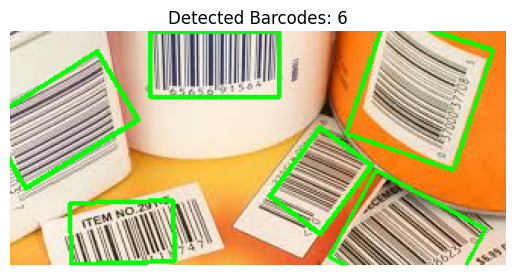

In [7]:
# First pass: collect all candidates
for cnt in contours:
    area = cv.contourArea(cnt)
    x, y, w, h = cv.boundingRect(cnt)

    # Check if this might be merged barcodes
    # Consider both area and aspect ratio (very wide or very tall might be multiple)
    aspect_ratio = w / float(h) if h > 0 else 0
    # More aggressive detection: lower thresholds to catch more merged cases
    is_likely_merged = (area > LARGE_AREA_THRESHOLD) or \
                       (area > 2000 and (aspect_ratio > 3.5 or aspect_ratio < 0.3)) or \
                       (area > 1500 and (aspect_ratio > 4.5 or aspect_ratio < 0.22)) or \
                       (area > 1000 and (aspect_ratio > 6.0 or aspect_ratio < 0.17))

    if is_likely_merged:
        # Extract ROI from the mask
        roi_mask = mask[y:y+h, x:x+w].copy()

        # Try to split it
        split_candidates = split_large_contour(roi_mask, x, y, img_w, img_h)

        if len(split_candidates) == 0:
            # If splitting failed, process as single (might be one large barcode)
            candidate = validate_contour(cnt, img_w, img_h)
            if candidate:
                barcode_candidates.append(candidate)
        else:
            barcode_candidates.extend(split_candidates)
    else:
        # Normal processing for regular-sized contours
        candidate = validate_contour(cnt, img_w, img_h)
        if candidate:
            barcode_candidates.append(candidate)

# Apply Non-Maximum Suppression to remove overlapping detections
# Lower IoU threshold (0.15) for more aggressive suppression, distance threshold of 50 pixels
final_detections = non_max_suppression(barcode_candidates, iou_threshold=0.15, distance_threshold=50)

# Draw the final filtered detections
for detection in final_detections:
    cv.drawContours(output, [detection['box']], 0, (0, 255, 0), 2)

barcode_count = len(final_detections)
print("Detected barcode candidates:", barcode_count)
plt.imshow(cv.cvtColor(output, cv.COLOR_BGR2RGB))
plt.title(f"Detected Barcodes: {barcode_count}")
plt.axis('off')
plt.show()